In [14]:
import pandas as pd
import os
import gzip
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import polars as pl
import umap
import glob
import umap

In [52]:
# load combined env data
env_filename = 'combined_env_si_airtemp_01.parquet'
env_path = os.path.join('../data/env', env_filename)
df_env = pd.read_parquet(env_path)

In [53]:
df_env.head()

,Timestamp,Tair,Si,Campaign
0,2000-03-12 22:22:05+00:00,15.018,-0.322695,ARM
1,2000-03-12 22:22:05.250000+00:00,15.028,-0.323351,ARM
2,2000-03-12 22:22:05.500000+00:00,15.028,-0.316420,ARM
3,2000-03-12 22:22:05.750000+00:00,15.031,-0.313372,ARM
4,2000-03-12 22:22:06+00:00,15.025,-0.313173,ARM


In [55]:
df_env.dtypes

Timestamp    datetime64[ns, UTC]
Tair                     float64
Si                       float64
Campaign                  object
dtype: object

In [10]:
# load cpi3m embeddings (from SSL Model v3)
cpi3m_path = "/home/jko/ssl-cpi-analysis/data/SSL-Model-v3/cpi3m_campaign_cls_head_features_compressed.parquet"
scan = pl.scan_parquet(cpi3m_path)

campaigns = [
    "CRYSTAL_FACE_NASA",
    "ARM",
    "CRYSTAL_FACE_UND",
    "MIDCIX",
    "MC3E",
]

cpi3m_selected = (
    scan
    .filter(pl.col("campaign").is_in(campaigns))
    .collect()
)

print(type(cpi3m_selected))
print(cpi3m_selected.head())


<class 'polars.dataframe.frame.DataFrame'>
shape: (5, 5)
┌────────────────────────┬──────────────┬──────────┬───────────────────────┬───────────────────────┐
│ campaign_file_id       ┆ cls_features ┆ campaign ┆ filename              ┆ head_features         │
│ ---                    ┆ ---          ┆ ---      ┆ ---                   ┆ ---                   │
│ str                    ┆ list[f32]    ┆ str      ┆ str                   ┆ list[f32]             │
╞════════════════════════╪══════════════╪══════════╪═══════════════════════╪═══════════════════════╡
│ ARM/2000_0306_202027_5 ┆ [1.024477,   ┆ ARM      ┆ 2000_0306_202027_531_ ┆ [0.06622, -0.005036,  │
│ 31_20.pn…              ┆ 1.715163, …  ┆          ┆ 20.png                ┆ … -0.0933…            │
│                        ┆ 1.07379…     ┆          ┆                       ┆                       │
│ ARM/2000_0306_202027_5 ┆ [0.983172,   ┆ ARM      ┆ 2000_0306_202027_531_ ┆ [0.053725, 0.029565,  │
│ 31_27.pn…              ┆ 0.97981

In [12]:
# number of samples per campaign
counts = (
    cpi3m_selected
    .group_by("campaign")
    .count()
    .sort("campaign")
)

print(counts)

shape: (5, 2)
┌───────────────────┬─────────┐
│ campaign          ┆ count   │
│ ---               ┆ ---     │
│ str               ┆ u32     │
╞═══════════════════╪═════════╡
│ ARM               ┆ 295703  │
│ CRYSTAL_FACE_NASA ┆ 78152   │
│ CRYSTAL_FACE_UND  ┆ 1617826 │
│ MC3E              ┆ 187558  │
│ MIDCIX            ┆ 90761   │
└───────────────────┴─────────┘


/tmp/tmp.8A5nzs2CyU/ipykernel_441794/3430549642.py:5: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  .count()


In [ ]:
# Lazy scan
lf = pl.scan_parquet(cpi3m_path)

# Get unique campaign values
campaigns = (
    lf.select("campaign")
      .unique()
      .collect()
)

print(campaigns['campaign'].to_list())

In [ ]:
lf = pl.scan_parquet(cpi3m_path)

result = (
    lf.select(["campaign", "filename"])
      .group_by("campaign")
      .agg(
          pl.col("filename").head(5).alias("filenames")
      )
      .collect()
)

for row in result.iter_rows(named=True):
    print(f"\nCampaign: {row['campaign']}")
    for f in row["filenames"]:
        print(f"  {f}")

In [13]:
# sample random subset of each campaign
n_per_campaign = 75_000

cpi3m_sampled = (
    cpi3m_selected
    .group_by("campaign")
    .agg(
        pl.all().sample(n=n_per_campaign, with_replacement=False)
    )
    .explode(pl.all().exclude("campaign"))
)

print(cpi3m_sampled.shape)

(375000, 5)


In [15]:
# UMAP to reduce embeddings to 3-D 
X = cpi3m_sampled['cls_features'].to_list()
X = np.array(X, dtype=np.float32)
print("Embedding matrix:", X.shape)
# Run UMAP → 3 dimensions
umap_model = umap.UMAP(
    n_components=3,
    n_neighbors=100,
    min_dist=0.1,
    metric="cosine",
    n_jobs=-1
    # random_state=42,
)

X_umap = umap_model.fit_transform(X)
print("UMAP shape:", X_umap.shape)

Embedding matrix: (375000, 384)
UMAP shape: (375000, 3)


In [17]:
# Save UMAP embeddings
save_dir = '../data/umap'
save_filename = 'umap_d3_n375k.csv'
save_filepath = os.path.join(save_dir, save_filename)
np.savetxt(
    save_filepath,
    X_umap,
    delimiter=","
)

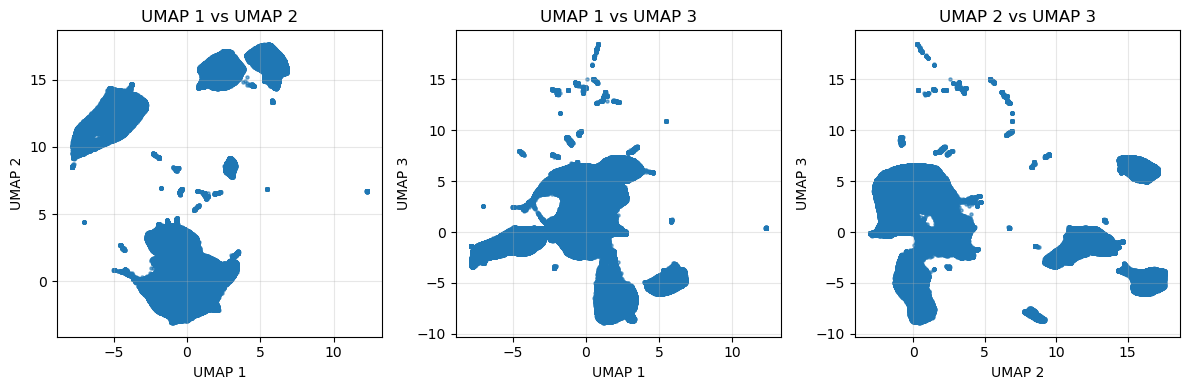

In [18]:
# plot UMAP in 3D
# Convert to named columns for clarity
umap1 = X_umap[:, 0]
umap2 = X_umap[:, 1]
umap3 = X_umap[:, 2]

# Create figure with 3 subplots
plt.figure(figsize=(12, 4))

# ---- Plot 1: UMAP1 vs UMAP2 ----
plt.subplot(1, 3, 1)
plt.scatter(umap1, umap2, s=5, alpha=0.6)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP 1 vs UMAP 2")
plt.grid(alpha=0.3)

# ---- Plot 2: UMAP1 vs UMAP3 ----
plt.subplot(1, 3, 2)
plt.scatter(umap1, umap3, s=5, alpha=0.6)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 3")
plt.title("UMAP 1 vs UMAP 3")
plt.grid(alpha=0.3)

# ---- Plot 3: UMAP2 vs UMAP3 ----
plt.subplot(1, 3, 3)
plt.scatter(umap2, umap3, s=5, alpha=0.6)
plt.xlabel("UMAP 2")
plt.ylabel("UMAP 3")
plt.title("UMAP 2 vs UMAP 3")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# normalize UMAP embeddings to RGB
# Assume X_umap is (N, 3)
umap_norm = (X_umap - X_umap.min(axis=0)) / (X_umap.max(axis=0) - X_umap.min(axis=0))
umap_norm = np.clip(umap_norm, 0, 1)       # safety

# Convert to 0–255 uint8 RGB
rgb = (umap_norm * 255).astype(np.uint8)

print(rgb.shape)   # (N, 3)

(375000, 3)


In [23]:
cpi3m_sampled = cpi3m_sampled.with_columns(
    pl.col("filename")
      .str.split("_")
      .list.slice(0, 3)
      .list.join("_")
      .str.strptime(pl.Datetime, format="%Y_%m%d_%H%M%S")
      .alias("timestamp")
)

print(cpi3m_sampled.select(["filename", "timestamp"]).head())

shape: (5, 2)
┌─────────────────────────────┬─────────────────────┐
│ filename                    ┆ timestamp           │
│ ---                         ┆ ---                 │
│ str                         ┆ datetime[μs]        │
╞═════════════════════════════╪═════════════════════╡
│ 2002_0729_200036_761_43.png ┆ 2002-07-29 20:00:36 │
│ 2002_0728_222230_644_29.png ┆ 2002-07-28 22:22:30 │
│ 2002_0723_202758_986_41.png ┆ 2002-07-23 20:27:58 │
│ 2002_0729_200202_530_0.png  ┆ 2002-07-29 20:02:02 │
│ 2002_0729_192302_10_37.png  ┆ 2002-07-29 19:23:02 │
└─────────────────────────────┴─────────────────────┘


In [24]:
cpi3m_sampled = cpi3m_sampled.with_columns([
    pl.Series("r", rgb[:, 0]),
    pl.Series("g", rgb[:, 1]),
    pl.Series("b", rgb[:, 2]),
])

print(cpi3m_sampled.select(["r", "g", "b"]).head())

shape: (5, 3)
┌─────┬─────┬─────┐
│ r   ┆ g   ┆ b   │
│ --- ┆ --- ┆ --- │
│ u8  ┆ u8  ┆ u8  │
╞═════╪═════╪═════╡
│ 119 ┆ 37  ┆ 3   │
│ 123 ┆ 42  ┆ 10  │
│ 113 ┆ 39  ┆ 38  │
│ 122 ┆ 36  ┆ 28  │
│ 119 ┆ 36  ┆ 4   │
└─────┴─────┴─────┘


In [25]:
cpi3m_sampled.head()

campaign,campaign_file_id,cls_features,filename,head_features,timestamp,r,g,b
str,str,list[f32],str,list[f32],datetime[μs],u8,u8,u8
"""CRYSTAL_FACE_NASA""","""CRYSTAL_FACE_NASA/2002_0728_23…","[0.471055, -1.806978, … -1.171663]","""2002_0729_200036_761_43.png""","[0.038345, 0.140147, … 0.052869]",2002-07-29 20:00:36,119,37,3
"""CRYSTAL_FACE_NASA""","""CRYSTAL_FACE_NASA/2002_0728_23…","[0.349439, -0.042943, … 0.223097]","""2002_0728_222230_644_29.png""","[-0.071031, 0.02049, … 0.174885]",2002-07-28 22:22:30,123,42,10
"""CRYSTAL_FACE_NASA""","""CRYSTAL_FACE_NASA/2002_0728_23…","[0.372375, -2.712676, … 2.649947]","""2002_0723_202758_986_41.png""","[0.176625, -0.02786, … 0.06416]",2002-07-23 20:27:58,113,39,38
"""CRYSTAL_FACE_NASA""","""CRYSTAL_FACE_NASA/2002_0711_18…","[0.934668, -1.814196, … 2.363677]","""2002_0729_200202_530_0.png""","[0.036291, 0.008446, … -0.007739]",2002-07-29 20:02:02,122,36,28
"""CRYSTAL_FACE_NASA""","""CRYSTAL_FACE_NASA/2002_0729_19…","[0.388089, -1.555072, … -0.601788]","""2002_0729_192302_10_37.png""","[0.08761, -0.075655, … 0.156968]",2002-07-29 19:23:02,119,36,4


In [35]:
cpi3m_sampled.columns

['Campaign',
 'campaign_file_id',
 'cls_features',
 'filename',
 'head_features',
 'timestamp',
 'r',
 'g',
 'b']

In [36]:
# rename column name and campaigns to match env df
cpi3m_sampled = (
    cpi3m_sampled
    # # rename column
    # .rename({"campaign": "Campaign"})
    # replace values
    .with_columns(
        pl.col("Campaign")
        .replace({
            "CRYSTAL_FACE_UND": "CRYSTAL-FACE-UND",
            "CRYSTAL_FACE_NASA": "CRYSTAL-FACE-NASA",
        })
    )
)
df_cpi = cpi3m_sampled
df_cpi['Campaign'].unique()

Campaign
str
"""CRYSTAL-FACE-NASA"""
"""MC3E"""
"""CRYSTAL-FACE-UND"""
"""ARM"""
"""MIDCIX"""


In [39]:
df_cpi.head()

Campaign,campaign_file_id,cls_features,filename,head_features,timestamp,r,g,b
str,str,list[f32],str,list[f32],datetime[μs],u8,u8,u8
"""CRYSTAL-FACE-NASA""","""CRYSTAL_FACE_NASA/2002_0728_23…","[0.471055, -1.806978, … -1.171663]","""2002_0729_200036_761_43.png""","[0.038345, 0.140147, … 0.052869]",2002-07-29 20:00:36,119,37,3
"""CRYSTAL-FACE-NASA""","""CRYSTAL_FACE_NASA/2002_0728_23…","[0.349439, -0.042943, … 0.223097]","""2002_0728_222230_644_29.png""","[-0.071031, 0.02049, … 0.174885]",2002-07-28 22:22:30,123,42,10
"""CRYSTAL-FACE-NASA""","""CRYSTAL_FACE_NASA/2002_0728_23…","[0.372375, -2.712676, … 2.649947]","""2002_0723_202758_986_41.png""","[0.176625, -0.02786, … 0.06416]",2002-07-23 20:27:58,113,39,38
"""CRYSTAL-FACE-NASA""","""CRYSTAL_FACE_NASA/2002_0711_18…","[0.934668, -1.814196, … 2.363677]","""2002_0729_200202_530_0.png""","[0.036291, 0.008446, … -0.007739]",2002-07-29 20:02:02,122,36,28
"""CRYSTAL-FACE-NASA""","""CRYSTAL_FACE_NASA/2002_0729_19…","[0.388089, -1.555072, … -0.601788]","""2002_0729_192302_10_37.png""","[0.08761, -0.075655, … 0.156968]",2002-07-29 19:23:02,119,36,4


In [37]:
df_env['Campaign'].unique()

array(['ARM', 'CRYSTAL-FACE-NASA', 'CRYSTAL-FACE-UND', 'MC3E', 'MIDCIX',
       'OLYMPEX'], dtype=object)

In [38]:
df_env.head()

,Timestamp,Tair,Si,Campaign
0,2000-03-12 22:22:05+00:00,15.018,-0.322695,ARM
1,2000-03-12 22:22:05.250000+00:00,15.028,-0.323351,ARM
2,2000-03-12 22:22:05.500000+00:00,15.028,-0.316420,ARM
3,2000-03-12 22:22:05.750000+00:00,15.031,-0.313372,ARM
4,2000-03-12 22:22:06+00:00,15.025,-0.313173,ARM


In [46]:
na_count_env = df_env["Timestamp"].isna().sum()
print(f"df_env has {na_count_env} missing Timestamp values")
print(f"{na_count_env / len(df_env) * 100:.2f}% of df_env timestamps are missing")

df_env has 743873 missing Timestamp values
70.54% of df_env timestamps are missing


In [47]:
na_count_cpi = df_cpi.select(
    pl.col("timestamp").is_null().sum().alias("n_missing")
)["n_missing"][0]

print(f"df_cpi has {na_count_cpi} missing timestamp values")
print(f"{na_count_cpi / df_cpi.height * 100:.2f}% of df_cpi timestamps are missing")

df_cpi has 0 missing timestamp values
0.00% of df_cpi timestamps are missing


In [60]:
import polars as pl

# -----------------------------
# Step 0: Prepare CPI timestamps
# -----------------------------
# Round CPI timestamps to nearest second and make naive (no timezone)
df_cpi_temp = df_cpi.with_columns(
    pl.col("timestamp")
    .dt.round("1s")
    .dt.replace_time_zone(None)  # make naive for joining
    .alias("cpi_ts_rounded")
)

# -----------------------------
# Step 1: Prepare Environmental Data
# -----------------------------
# Ensure Timestamp is datetime64[ns, UTC] (already is if loaded correctly)
# Round to nearest second
df_env["Timestamp_rounded"] = df_env["Timestamp"].dt.round("1s")

# Convert to Polars and make naive for join
df_env_pl = (
    pl.from_pandas(df_env[["Campaign", "Timestamp_rounded", "Tair", "Si"]])
    .with_columns(
        pl.col("Timestamp_rounded")
        .cast(pl.Datetime)
        .dt.replace_time_zone(None)
    )
    .rename({"Timestamp_rounded": "env_ts_rounded"})  # avoid column name collisions
)

# -----------------------------
# Step 2: Merge CPI and Environmental Measurements
# -----------------------------
df_merged = df_cpi_temp.join(
    df_env_pl,
    left_on=["Campaign", "cpi_ts_rounded"],
    right_on=["Campaign", "env_ts_rounded"],
    how="inner"  # only keep CPI samples that have matching env measurements
)

# -----------------------------
# Step 3: Clean up helper columns
# -----------------------------
# Drop rounding columns safely
for col in ["cpi_ts_rounded", "env_ts_rounded"]:
    if col in df_merged.columns:
        df_merged = df_merged.drop(col)

# -----------------------------
# Step 4: Quick check
# -----------------------------
df_merged.head()

Campaign,campaign_file_id,cls_features,filename,head_features,timestamp,r,g,b,Tair,Si
str,str,list[f32],str,list[f32],datetime[μs],u8,u8,u8,f64,f64
"""ARM""","""ARM/2000_0319_154410_953_145.p…","[-1.728574, -0.066141, … -0.833292]","""2000_0312_224519_895_6.png""","[0.097287, 0.276726, … -0.15086]",2000-03-12 22:45:19,122,25,112,-15.176,-0.132572
"""ARM""","""ARM/2000_0313_011457_476_32.pn…","[0.095013, 0.932356, … 0.687107]","""2000_0312_224519_895_3.png""","[-0.18529, 0.157329, … 0.035862]",2000-03-12 22:45:19,101,41,138,-15.176,-0.132572
"""ARM""","""ARM/2000_0313_000618_896_22.pn…","[0.515553, -0.171747, … -1.718153]","""2000_0312_224519_895_26.png""","[0.208002, -0.205754, … 0.168212]",2000-03-12 22:45:19,92,19,83,-15.176,-0.132572
"""ARM""","""ARM/2000_0319_154410_953_145.p…","[-1.728574, -0.066141, … -0.833292]","""2000_0312_224519_895_6.png""","[0.097287, 0.276726, … -0.15086]",2000-03-12 22:45:19,122,25,112,-15.176,-0.13322
"""ARM""","""ARM/2000_0313_011457_476_32.pn…","[0.095013, 0.932356, … 0.687107]","""2000_0312_224519_895_3.png""","[-0.18529, 0.157329, … 0.035862]",2000-03-12 22:45:19,101,41,138,-15.176,-0.13322


In [62]:
len(df_merged)

305272

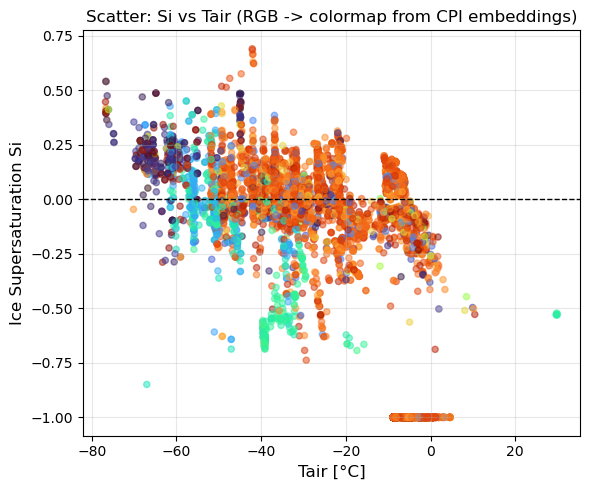

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import colorsys
import polars as pl

# -----------------------------
# Step 0: Sample points for plotting (optional)
# -----------------------------
# Convert Polars to Pandas for easy plotting
# n_samples = len(df_merged)
n_samples=10_000
df_plot = df_merged.select(["Tair", "Si", "r", "g", "b"]).sample(n=n_samples, seed=42).to_pandas()

# -----------------------------
# Step 1: Convert RGB 0-255 -> 0-1 floats
# -----------------------------
rgb_vals = df_plot[["r", "g", "b"]].values / 255.0

# -----------------------------
# Step 2: Convert RGB -> HSV -> Hue
# -----------------------------
hsv = np.array([colorsys.rgb_to_hsv(r, g, b) for r, g, b in rgb_vals])
hue = hsv[:, 0]  # 0..1

# -----------------------------
# Step 3: Map hue to matplotlib colormap
# -----------------------------
cmap = plt.cm.turbo
colors = cmap(hue)

# -----------------------------
# Step 4: Scatter plot
# -----------------------------
plt.figure(figsize=(6, 5))
plt.scatter(
    df_plot["Tair"],
    df_plot["Si"],
    c=colors,
    s=20,
    alpha=0.5
)

# Horizontal line at Si=0
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.xlabel("Tair [°C]", fontsize=12)
plt.ylabel("Ice Supersaturation Si", fontsize=12)
plt.title("Scatter: Si vs Tair (RGB -> colormap from CPI embeddings)", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

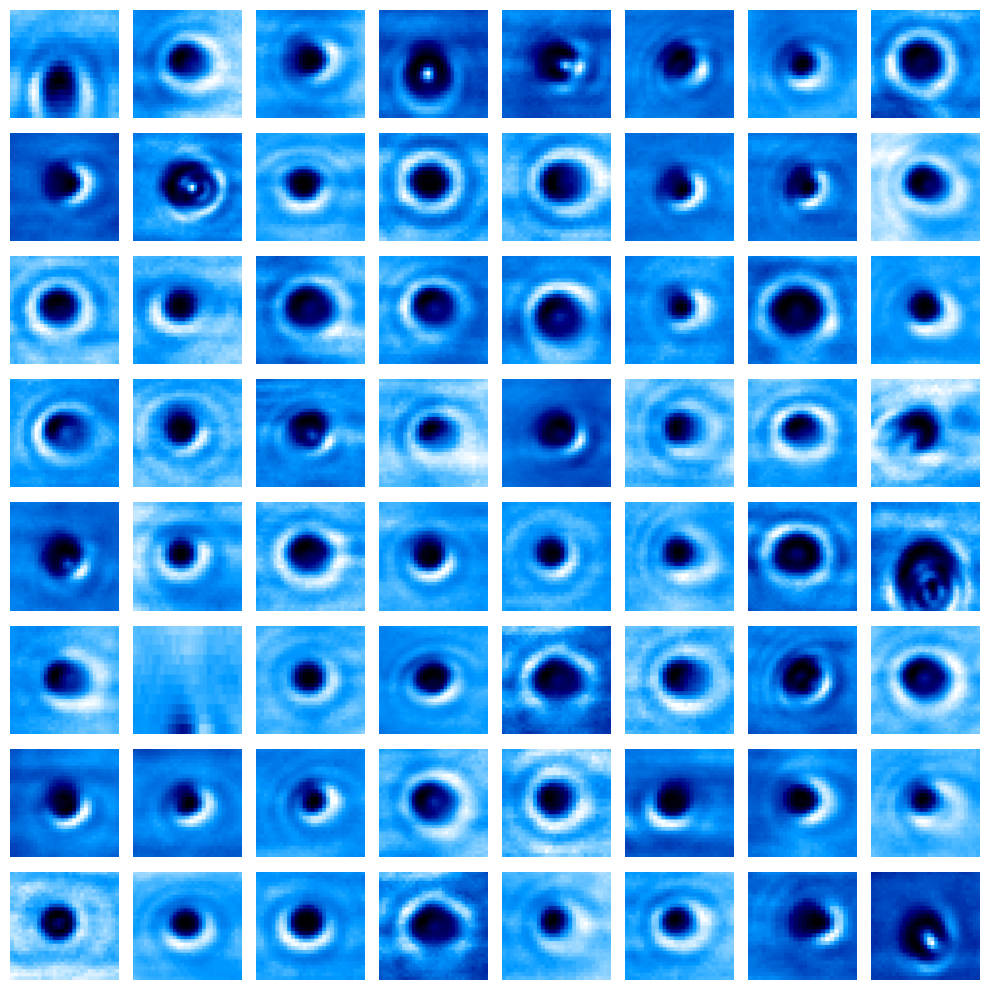

In [93]:
# Show samples of CPI images within user-defined extent.
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# -----------------------------
# Step 0: Define selection criteria
# -----------------------------
cpi_base_dir = '/home/vanessa/hulk/cocpit/cpi_data/campaigns'
tmin, tmax = -10, 0       # Tair extent
smin, smax = 0, 0.25    # Si extent
n_samples = 64            # number of images to plot

# -----------------------------
# Step 1: Filter df_merged based on Tair and Si
# -----------------------------
df_filtered = df_merged.filter(
    (pl.col("Tair") >= tmin) & (pl.col("Tair") <= tmax) &
    (pl.col("Si") >= smin) & (pl.col("Si") <= smax)
)

# -----------------------------
# Step 2: Sample n_samples images
# -----------------------------
n_available = df_filtered.height
n_take = min(n_samples, n_available)
df_sampled = df_filtered.sample(n=n_take, seed=42)

# -----------------------------
# Step 3: Map campaigns to directory names
# -----------------------------
campaign_dir_map = {
    "CRYSTAL-FACE-NASA": "CRYSTAL_FACE_NASA",
    "CRYSTAL-FACE-UND": "CRYSTAL_FACE_UND",
    # other campaigns map directly
    "ARM": "ARM",
    "MIDCIX": "MIDCIX",
    "MC3E": "MC3E",
    "OLYMPEX": "OLYMPEX"
}

# -----------------------------
# Step 4: Prepare image paths
# -----------------------------
image_paths = []
for row in df_sampled.to_dicts():
    campaign_dir = campaign_dir_map.get(row["Campaign"], row["Campaign"])
    img_path = os.path.join(
        cpi_base_dir,
        campaign_dir,
        "single_imgs_v1.4.0",
        os.path.basename(row["filename"])
    )
    image_paths.append(img_path)

# -----------------------------
# Step 5: Load images
# -----------------------------
images = []
for path in image_paths:
    if os.path.exists(path):
        img = Image.open(path).convert("RGB")
        images.append(img)
    else:
        print(f"Warning: {path} does not exist")
        images.append(Image.new("RGB", (64, 64), (0, 0, 0)))  # black placeholder

# -----------------------------
# Step 6: Plot images in a grid
# -----------------------------
grid_size = int(np.ceil(np.sqrt(n_take)))  # make square-ish grid
fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    if i < n_take:
        ax.imshow(images[i])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# TO-DO

# Bin relative percent of classes by temp/Si (use supervised labels)

# Ask CPI people spheres. Paul Lawson? Greg M.? 

# expand on similarity metrics as function of thermodynamic variables
